# 3 — Model Selection

Notebook di **sperimentazione e selezione del modello**. 
Confrontiamo 4 modelli con Cross-Validation 5-Fold, analizziamo l'overfitting (Train vs Validation) e valutiamo il modello vincitore sul Test Set.

---

## 3.1 — Setup & Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('✅ Librerie caricate.')

✅ Librerie caricate.


In [2]:
# --- Caricamento Dataset ---
train_df = pd.read_csv('../data/processed/KICKSTARTER_TRAIN.csv')
test_df  = pd.read_csv('../data/processed/KICKSTARTER_TEST.csv')

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test  = test_df.drop('target', axis=1)
y_test  = test_df['target']

print(f'📊 Training Set: {X_train.shape}')
print(f'📊 Test Set:     {X_test.shape}')
print(f'\n📊 Distribuzione Target (Train):\n{y_train.value_counts(normalize=True).round(4)}')

📊 Training Set: (150491, 367)
📊 Test Set:     (37623, 367)

📊 Distribuzione Target (Train):
target
1    0.6217
0    0.3783
Name: proportion, dtype: float64


---
## 3.2 — Definizione Modelli

Definiamo un dizionario con i 4 modelli candidati. 
La **Logistic Regression** è incapsulata in una `Pipeline` con `StandardScaler` perché è sensibile alla scala delle feature.

In [3]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    
    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),
    
    'LightGBM': LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

print(f'🔧 Modelli definiti: {list(models.keys())}')

🔧 Modelli definiti: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


---
## 3.3 — Cross-Validation 5-Fold

Eseguiamo la Cross-Validation con `return_train_score=True` per poter analizzare l'overfitting (gap tra Train e Validation score).

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

for name, model in models.items():
    print(f'⏳ Cross-Validation per {name}...')
    result = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    cv_results[name] = result
    
    # Stampa rapida
    val_f1 = np.mean(result['test_f1'])
    train_f1 = np.mean(result['train_f1'])
    print(f'   ✅ Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Gap: {train_f1 - val_f1:.4f}')

print('\n🎉 Cross-Validation completata per tutti i modelli.')

⏳ Cross-Validation per Logistic Regression...
   ✅ Train F1: 0.8427 | Val F1: 0.8411 | Gap: 0.0016
⏳ Cross-Validation per Random Forest...
   ✅ Train F1: 0.8349 | Val F1: 0.8141 | Gap: 0.0208
⏳ Cross-Validation per XGBoost...
   ✅ Train F1: 0.8569 | Val F1: 0.8467 | Gap: 0.0102
⏳ Cross-Validation per LightGBM...
   ✅ Train F1: 0.8675 | Val F1: 0.8482 | Gap: 0.0193

🎉 Cross-Validation completata per tutti i modelli.


---
## 3.4 — Tabella di Confronto: Train vs Validation (Analisi Overfitting)

Costruiamo una tabella che mostra, per ogni modello, le metriche medie di Train e Validation, più il **gap** (Train − Val). 
Un gap elevato è sintomo di **overfitting**.

In [5]:
rows = []

for name, result in cv_results.items():
    for metric in scoring:
        train_mean = np.mean(result[f'train_{metric}'])
        train_std  = np.std(result[f'train_{metric}'])
        val_mean   = np.mean(result[f'test_{metric}'])
        val_std    = np.std(result[f'test_{metric}'])
        gap        = train_mean - val_mean
        
        rows.append({
            'Model': name,
            'Metric': metric.upper(),
            'Train (mean ± std)': f'{train_mean:.4f} ± {train_std:.4f}',
            'Val (mean ± std)': f'{val_mean:.4f} ± {val_std:.4f}',
            'Gap (Train-Val)': f'{gap:.4f}',
            'train_val': train_mean,
            'val_val': val_mean,
            'gap_val': gap
        })

comparison_df = pd.DataFrame(rows)

# Tabella formattata (senza colonne numeriche grezze)
display_df = comparison_df[['Model', 'Metric', 'Train (mean ± std)', 'Val (mean ± std)', 'Gap (Train-Val)']]
display_df

,Model,Metric,Train (mean ± std),Val (mean ± std),Gap (Train-Val)
0,Logistic Regression,ACCURACY,0.8001 ± 0.0004,0.7980 ± 0.0015,0.0020
1,Logistic Regression,PRECISION,0.8248 ± 0.0004,0.8233 ± 0.0025,0.0015
2,Logistic Regression,RECALL,0.8614 ± 0.0004,0.8596 ± 0.0025,0.0018
3,Logistic Regression,F1,0.8427 ± 0.0003,0.8411 ± 0.0010,0.0016
4,Logistic Regression,ROC_AUC,0.8759 ± 0.0003,0.8738 ± 0.0013,0.0021
5,Random Forest,ACCURACY,0.8050 ± 0.0007,0.7807 ± 0.0013,0.0243
6,Random Forest,PRECISION,0.8813 ± 0.0019,0.8604 ± 0.0015,0.0208
7,Random Forest,RECALL,0.7931 ± 0.0020,0.7725 ± 0.0026,0.0206
8,Random Forest,F1,0.8349 ± 0.0006,0.8141 ± 0.0013,0.0208
9,Random Forest,ROC_AUC,0.8980 ± 0.0004,0.8698 ± 0.0016,0.0282


### Tabella Riassuntiva per Modello (solo Validation)

In [10]:
# Pivot: righe = modelli, colonne = metriche (solo validazione)
summary_rows = []
for name, result in cv_results.items():
    row = {'Model': name}
    for metric in scoring:
        row[metric.upper()] = np.mean(result[f'test_{metric}'])
    row['Avg Gap'] = np.mean([
        np.mean(result[f'train_{m}']) - np.mean(result[f'test_{m}'])
        for m in scoring
    ])
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index('Model')
metric_cols = [m.upper() for m in scoring]
summary_df.style.format('{:.4f}').background_gradient(cmap='YlGn', subset=metric_cols).background_gradient(
    cmap='YlOrRd', subset=['Avg Gap']
)

,ACCURACY,PRECISION,RECALL,F1,ROC_AUC,Avg Gap
Model,,,,,,
Logistic Regression,0.7980,0.8233,0.8596,0.8411,0.8738,0.0018
Random Forest,0.7807,0.8604,0.7725,0.8141,0.8698,0.0229
XGBoost,0.8038,0.8234,0.8714,0.8467,0.8825,0.0115
LightGBM,0.8065,0.8279,0.8695,0.8482,0.8855,0.0217


---
## 3.5 — Grafici di Confronto

### Bar Chart — Train vs Validation per Metrica

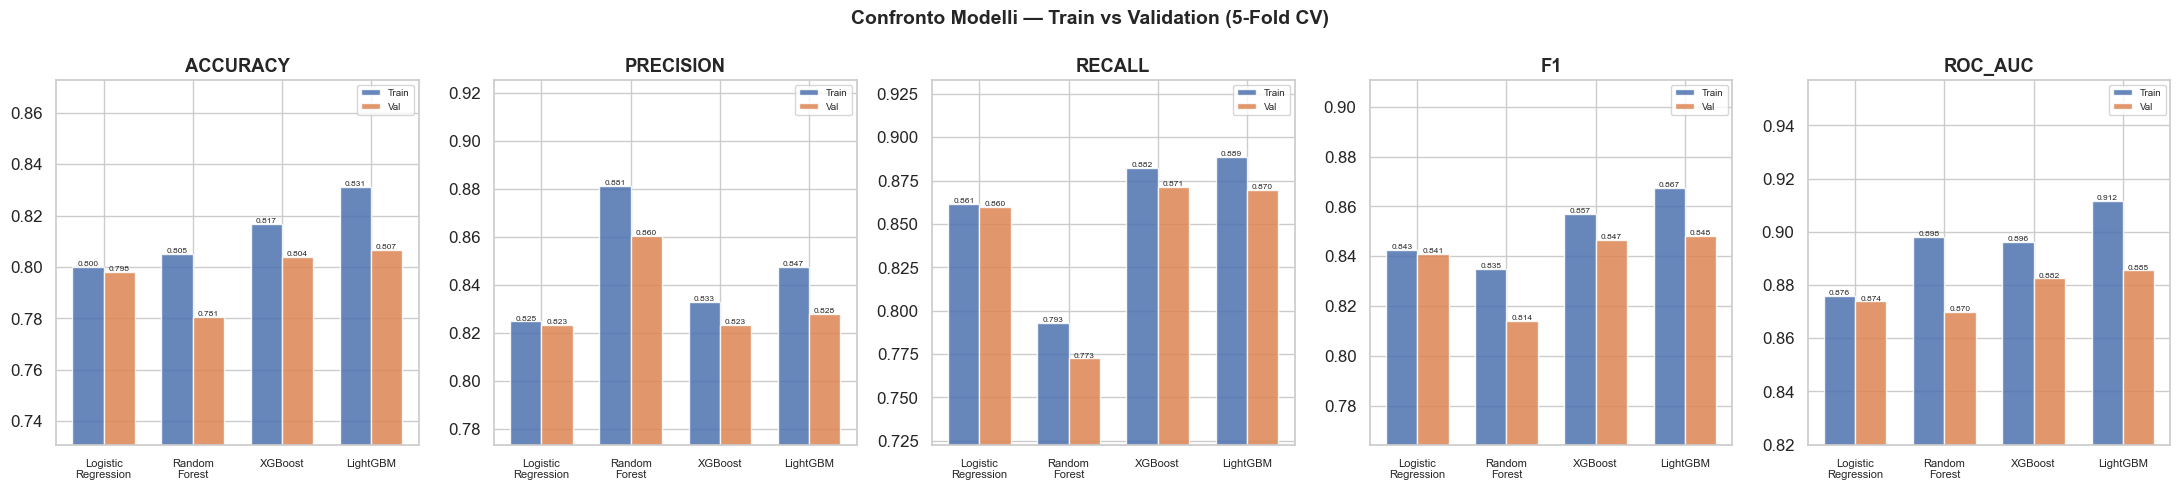

In [11]:
fig, axes = plt.subplots(1, len(scoring), figsize=(22, 5), sharey=False)

model_names = list(cv_results.keys())
x = np.arange(len(model_names))
width = 0.35

for i, metric in enumerate(scoring):
    ax = axes[i]
    train_vals = [np.mean(cv_results[m][f'train_{metric}']) for m in model_names]
    val_vals   = [np.mean(cv_results[m][f'test_{metric}'])  for m in model_names]
    
    bars_train = ax.bar(x - width/2, train_vals, width, label='Train', color='#4C72B0', alpha=0.85)
    bars_val   = ax.bar(x + width/2, val_vals,   width, label='Val',   color='#DD8452', alpha=0.85)
    
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
    ax.set_ylim(bottom=min(min(train_vals), min(val_vals)) - 0.05)
    ax.legend(fontsize=7)
    
    # Annota valori
    for bar in bars_train:
        ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=6)
    for bar in bars_val:
        ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=6)

fig.suptitle('Confronto Modelli — Train vs Validation (5-Fold CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Radar Chart — Profilo Metriche per Modello (Validation)

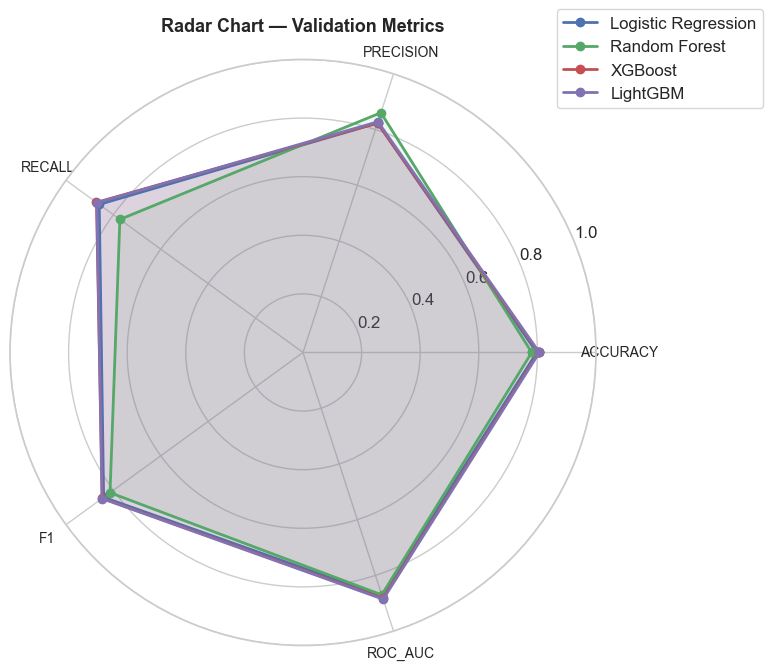

In [12]:
from math import pi

categories = [m.upper() for m in scoring]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # chiudi il poligono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for idx, (name, result) in enumerate(cv_results.items()):
    values = [np.mean(result[f'test_{m}']) for m in scoring]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Validation Metrics', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
## 3.6 — Scelta del Modello Vincitore

Sulla base delle metriche di Cross-Validation, il modello scelto è **LightGBM**:

- **Performance più alte** (o tra le più alte) su tutte le metriche di Validation  
- **Gap Train-Val contenuto**, indicando un buon trade-off tra capacità di apprendimento e generalizzazione  
- **Velocità di training** significativamente superiore a XGBoost con risultati comparabili  
- **Gestione nativa** dei valori mancanti e delle feature categoriche  

> **Modello vincitore: LightGBM**

---
## 3.7 — Valutazione Finale su Test Set (Solo LightGBM)

In [13]:
# Addestramento sul TRAINING SET completo
best_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('✅ LightGBM addestrato su tutto il Training Set e valutato su Test Set.')

✅ LightGBM addestrato su tutto il Training Set e valutato su Test Set.


### Classification Report

In [14]:
print('\n--- 📋 CLASSIFICATION REPORT (Test Set) ---\n')
print(classification_report(y_test, y_pred, target_names=['Failed (0)', 'Successful (1)']))


--- 📋 CLASSIFICATION REPORT (Test Set) ---

                precision    recall  f1-score   support

    Failed (0)       0.77      0.70      0.73     14234
Successful (1)       0.83      0.87      0.85     23389

      accuracy                           0.81     37623
     macro avg       0.80      0.79      0.79     37623
  weighted avg       0.80      0.81      0.80     37623



### Confusion Matrix

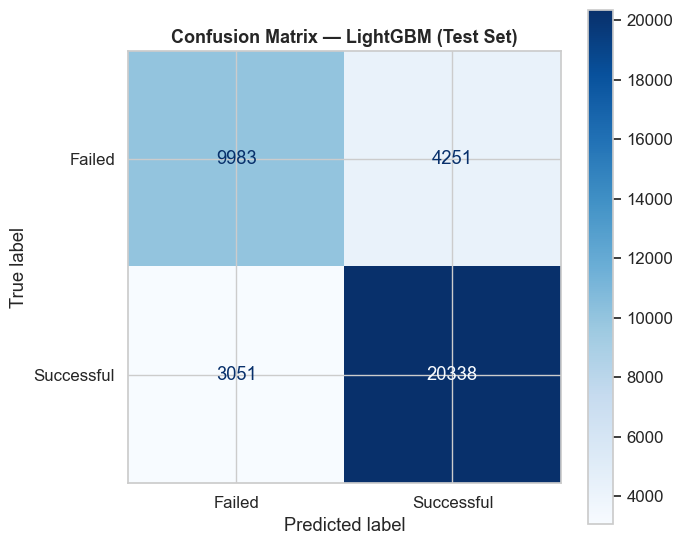

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failed', 'Successful'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix — LightGBM (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve

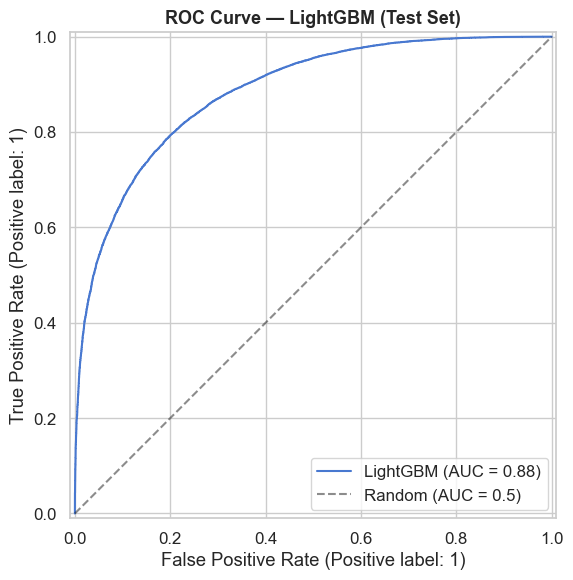


📊 AUC-ROC (Test Set): 0.8844


In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='LightGBM')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
ax.set_title('ROC Curve — LightGBM (Test Set)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n📊 AUC-ROC (Test Set): {roc_auc_score(y_test, y_proba):.4f}')

### Metriche Finali su Test Set

In [17]:
test_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1':        f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_proba)
}

test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df.style.format('{:.4f}')

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.8059,0.8271,0.8696,0.8478,0.8844


---
## 3.8 — Conclusioni

Il **LightGBM** è stato selezionato come modello finale per i seguenti motivi:

1. **Generalizzazione**: gap Train-Validation contenuto, segno di basso overfitting
2. **Performance**: metriche di Validation e Test Set coerenti con quelle osservate in CV
3. **Efficienza**: tempi di training ridotti rispetto a XGBoost a parità (o superiorità) di risultati
4. **Robustezza**: gestione nativa di valori mancanti e feature ad alta cardinalità

Il modello verrà addestrato in produzione tramite lo script `train_model.py` e salvato in `app/models/final_model.joblib`.

---
*Notebook di sperimentazione — KickProphet*